# Phase 1 — Exploratory Data Analysis (NSL-KDD)

**Goal:** understand the data *before* modelling, through a SOC analyst's lens.
Every plot below is followed by what it means operationally — not just what it
shows. Figures are saved to `results/figures/` for the write-up.

We look at: (1) the class landscape (normal vs attack, and the 4 attack
families), (2) train-vs-test **distribution shift**, (3) categorical protocol
behaviour, (4) feature correlations, and (5) how a few key features separate
attacks from normal traffic.

In [1]:
# --- bootstrap: paths, imports, plotting style ------------------------------
import sys
from pathlib import Path

# Find repo root whether run from repo root or from notebooks/.
_here = Path.cwd()
ROOT = _here if (_here / "src").is_dir() else _here.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data as D  # our src/data.py

FIG_DIR = ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = dict(zip(D.FAMILY_ORDER, sns.color_palette("colorblind", 5)))
pd.set_option("display.max_columns", 60)
np.random.seed(D.RANDOM_STATE)

def savefig(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"saved -> results/figures/{name}")

print("env ready. repo root:", ROOT.name)

env ready. repo root: nsl-kdd-ids


## 1. Load the official splits

We use the **official** `KDDTrain+` / `KDDTest+` split — not a random re-split.
The columns are the 41 NSL-KDD features + `label` + `difficulty`, plus two
derived label columns (`binary_label`, `attack_family`) added by `src/data.py`.

In [2]:
train = D.load_nsl_kdd("train")
test  = D.load_nsl_kdd("test")
print(f"train: {train.shape}   test: {test.shape}")
train.head(3)

train: (125973, 45)   test: (22544, 45)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,attack_family,binary_label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.0,150,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20,normal,0
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.0,255,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15,normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.0,255,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19,DoS,1


In [3]:
# Feature-type inventory
print(f"Categorical ({len(D.CATEGORICAL_COLS)}): {D.CATEGORICAL_COLS}")
for c in D.CATEGORICAL_COLS:
    print(f"   {c:13s} cardinality: train={train[c].nunique()}, test={test[c].nunique()}")
print(f"\nBinary 0/1 ({len(D.BINARY_COLS)}): {D.BINARY_COLS}")
print(f"Other numeric: {len(D.NUMERIC_COLS) - len(D.BINARY_COLS)}")
print(f"Zero-variance (all 0 in NSL-KDD): {D.ZERO_VARIANCE_COLS} "
      f"-> train std={train['num_outbound_cmds'].std():.4f}")

Categorical (3): ['protocol_type', 'service', 'flag']
   protocol_type cardinality: train=3, test=3
   service       cardinality: train=70, test=64
   flag          cardinality: train=11, test=11

Binary 0/1 (6): ['land', 'logged_in', 'root_shell', 'su_attempted', 'is_host_login', 'is_guest_login']
Other numeric: 32
Zero-variance (all 0 in NSL-KDD): ['num_outbound_cmds'] -> train std=0.0000


**Reading it (security view).** 41 features describe each connection at three
levels: *basic* (bytes, protocol, flag), *content* (login attempts, shell
access — hints of R2L/U2R), and *traffic statistics* over time/host windows
(the `count`/`*_rate`/`dst_host_*` features — the fingerprint of DoS and Probe).
`service` is high-cardinality (~70 values). A common claim is that the test
set holds unseen *services*; in these files that is actually **false** (all 64
test services appear in train). The real novelty is in **attack types**: 17
attack labels in the test set never appear in training (e.g. `apache2`,
`mscan`, `xterm`). We still use `handle_unknown="ignore"` as a correct,
defensive default — it costs nothing and is essential for the other datasets.
`num_outbound_cmds` is constant (all zero) — a known NSL-KDD quirk carrying no
signal.

## 2. Class distribution & the train→test shift

The single most important EDA finding in NSL-KDD.

In [4]:
def family_counts(df):
    return df["attack_family"].value_counts().reindex(D.FAMILY_ORDER)

ct = pd.DataFrame({"train": family_counts(train), "test": family_counts(test)})
ct["train %"] = (ct["train"] / ct["train"].sum() * 100).round(2)
ct["test %"]  = (ct["test"]  / ct["test"].sum()  * 100).round(2)
print("Attack-family distribution:")
print(ct)
print(f"\nBinary  train: attack={train['binary_label'].mean()*100:.1f}%  "
      f"test: attack={test['binary_label'].mean()*100:.1f}%")

Attack-family distribution:
               train  test  train %  test %
attack_family                              
normal         67343  9711    53.46   43.08
DoS            45927  7460    36.46   33.09
Probe          11656  2421     9.25   10.74
R2L              995  2885     0.79   12.80
U2R               52    67     0.04    0.30



Binary  train: attack=46.5%  test: attack=56.9%


saved -> results/figures/p1_class_distribution.png


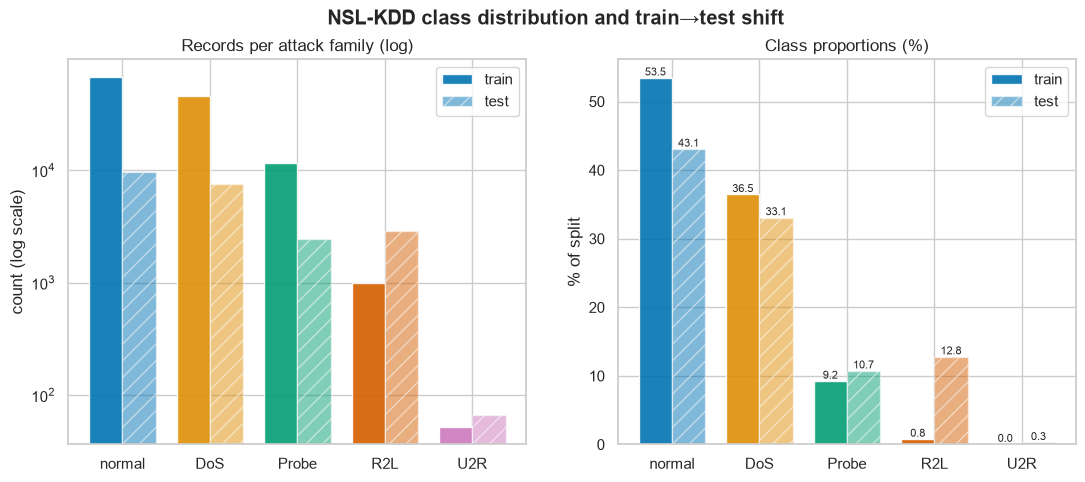

In [5]:
# Figure 1: class distribution, train vs test, counts (log) + proportions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(D.FAMILY_ORDER)); w = 0.38
colors = [PALETTE[f] for f in D.FAMILY_ORDER]

axes[0].bar(x - w/2, ct["train"], w, label="train", color=colors, alpha=0.9)
axes[0].bar(x + w/2, ct["test"],  w, label="test",  color=colors, alpha=0.5,
            hatch="//", edgecolor="white")
axes[0].set_yscale("log"); axes[0].set_ylabel("count (log scale)")
axes[0].set_title("Records per attack family (log)")
axes[0].set_xticks(x); axes[0].set_xticklabels(D.FAMILY_ORDER)
axes[0].legend()

axes[1].bar(x - w/2, ct["train %"], w, label="train", color=colors, alpha=0.9)
axes[1].bar(x + w/2, ct["test %"],  w, label="test",  color=colors, alpha=0.5,
            hatch="//", edgecolor="white")
axes[1].set_ylabel("% of split"); axes[1].set_title("Class proportions (%)")
axes[1].set_xticks(x); axes[1].set_xticklabels(D.FAMILY_ORDER)
for i, f in enumerate(D.FAMILY_ORDER):
    axes[1].annotate(f"{ct['train %'][f]:.1f}", (i - w/2, ct['train %'][f]),
                     ha="center", va="bottom", fontsize=8)
    axes[1].annotate(f"{ct['test %'][f]:.1f}", (i + w/2, ct['test %'][f]),
                     ha="center", va="bottom", fontsize=8)
axes[1].legend()
fig.suptitle("NSL-KDD class distribution and train→test shift", fontweight="bold")
savefig(fig, "p1_class_distribution.png"); plt.show()

**Reading it (security view).** Two things a SOC analyst should care about:

1. **Severe imbalance.** In training, U2R is **0.04%** and R2L **0.8%** of
   records, while DoS is ~36%. A classifier can hit ~99% *accuracy* by nailing
   normal+DoS and completely missing U2R — yet U2R (privilege escalation) is the
   most dangerous outcome. This is why we lead with **macro-F1 and per-class
   recall**, never accuracy.

2. **Distribution shift is deliberate.** R2L explodes from **0.8% → 12.8%** and
   U2R roughly triples in proportion from train to test, because the test set
   injects *new attack types* not seen in training. This mirrors real security
   ops — tomorrow's attacks aren't in yesterday's labelled data — and is exactly
   why the official split is harder and more honest than a random split, where
   train and test would be identically distributed and scores would look
   flatteringly high.

## 3. Which specific attacks dominate?

saved -> results/figures/p1_top_attack_types.png


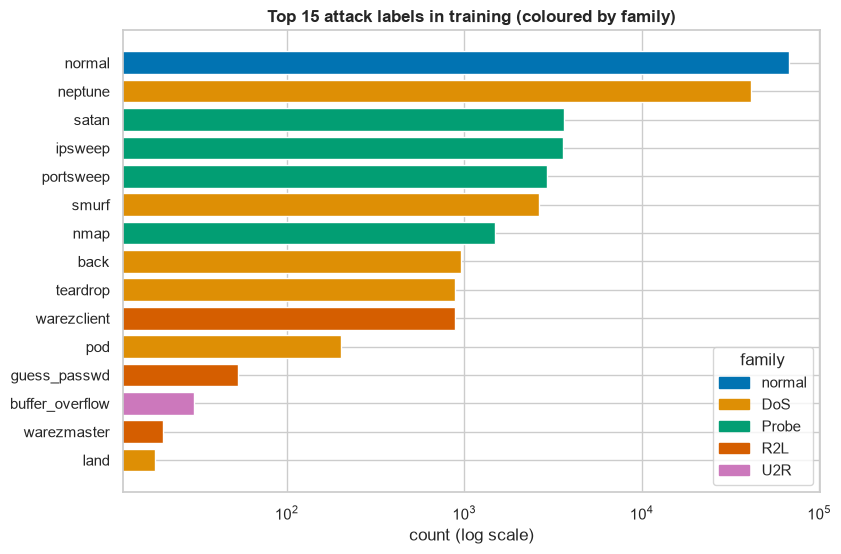

In [6]:
top = train["label"].value_counts().head(15)[::-1]
fam_of = train.drop_duplicates("label").set_index("label")["attack_family"]
bar_colors = [PALETTE[fam_of[l]] for l in top.index]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top.values, color=bar_colors)
ax.set_xscale("log"); ax.set_xlabel("count (log scale)")
ax.set_title("Top 15 attack labels in training (coloured by family)", fontweight="bold")
handles = [plt.Rectangle((0,0),1,1,color=PALETTE[f]) for f in D.FAMILY_ORDER]
ax.legend(handles, D.FAMILY_ORDER, title="family", loc="lower right")
savefig(fig, "p1_top_attack_types.png"); plt.show()

**Reading it (security view).** Within each family a handful of signatures
dominate: `neptune` (SYN-flood DoS) and `smurf` (ICMP-amplification DoS) make up
the bulk of attacks, and `satan`/`ipsweep`/`portsweep` dominate Probe. The long
tail — R2L/U2R attacks like `guess_passwd`, `buffer_overflow`, `rootkit` — has
tens of examples, not thousands. Models will be data-starved exactly where the
stakes are highest.

## 4. Categorical behaviour: protocol & flag by class

Protocol and TCP `flag` are cheap, high-signal features an analyst reads first.

saved -> results/figures/p1_categorical_by_class.png


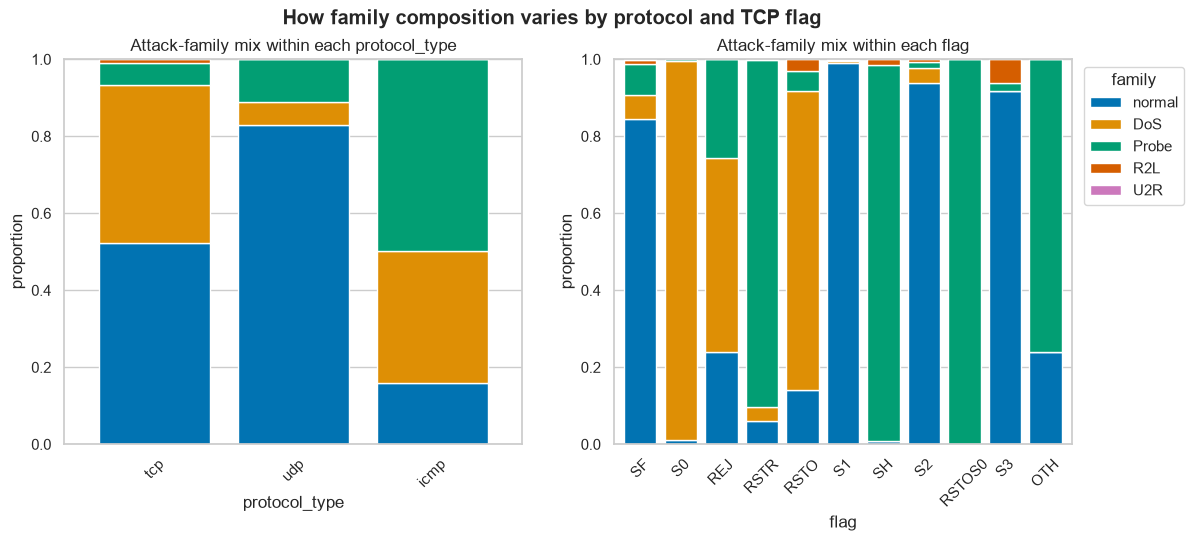

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ["protocol_type", "flag"]):
    ctab = (pd.crosstab(train[col], train["attack_family"], normalize="index")
              .reindex(columns=D.FAMILY_ORDER).fillna(0))
    ctab = ctab.loc[train[col].value_counts().index]  # order by frequency
    ctab.plot(kind="bar", stacked=True, ax=ax,
              color=[PALETTE[f] for f in D.FAMILY_ORDER], width=0.8, legend=False)
    ax.set_title(f"Attack-family mix within each {col}")
    ax.set_ylabel("proportion"); ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=45)
axes[1].legend(title="family", bbox_to_anchor=(1.01, 1), loc="upper left")
fig.suptitle("How family composition varies by protocol and TCP flag",
             fontweight="bold")
savefig(fig, "p1_categorical_by_class.png"); plt.show()

**Reading it (security view).** TCP `flag` is remarkably discriminative:
`S0` (connection attempted, no reply — the SYN-scan/SYN-flood signature) is
overwhelmingly attack, while `SF` (normal establish-and-finish) skews benign.
`REJ` (rejected) leans Probe. This is textbook DoS/Probe behaviour and explains
why tree models lean heavily on `flag` and the `serror_rate` features it
correlates with. Protocol alone is weaker but `icmp` carries the smurf/Probe
load.

## 5. Feature correlations

With 38 numeric features, blocks of redundancy tell us where signal
concentrates (and warn about multicollinearity for linear models).

saved -> results/figures/p1_correlation_heatmap.png


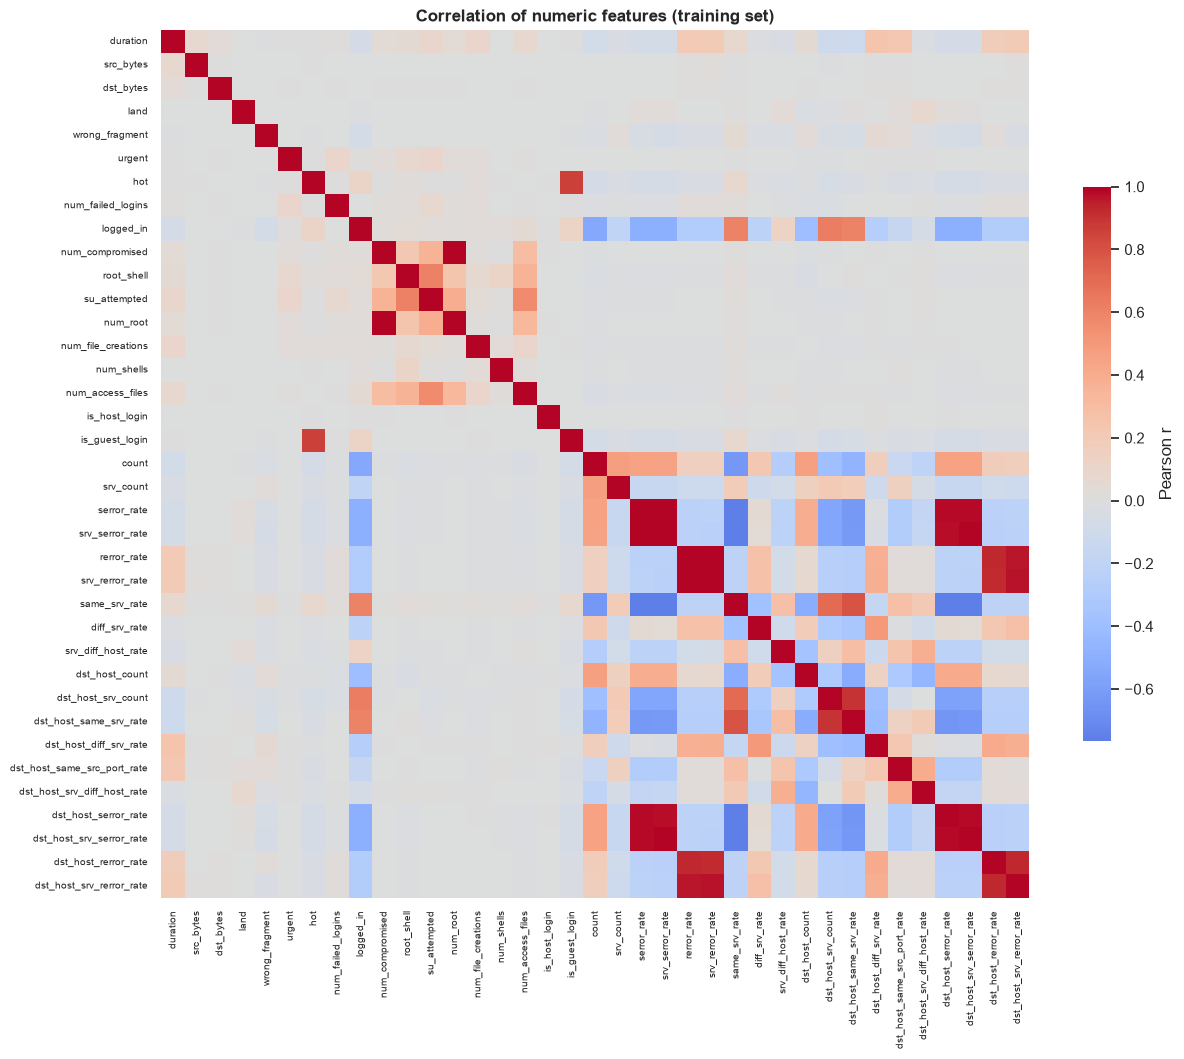

In [8]:
num = [c for c in D.NUMERIC_COLS if c not in D.ZERO_VARIANCE_COLS]
corr = train[num].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6, "label": "Pearson r"},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title("Correlation of numeric features (training set)", fontweight="bold")
ax.tick_params(labelsize=7)
savefig(fig, "p1_correlation_heatmap.png"); plt.show()

In [9]:
# Strongest correlated pairs (|r| > 0.9), for the write-up
cc = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
print("Highly correlated feature pairs (|r| > 0.9):")
print(cc[cc.abs() > 0.9].sort_values(key=abs, ascending=False).round(3).to_string())

Highly correlated feature pairs (|r| > 0.9):
num_compromised       num_root                    0.999
serror_rate           srv_serror_rate             0.993
rerror_rate           srv_rerror_rate             0.989
srv_serror_rate       dst_host_srv_serror_rate    0.986
dst_host_serror_rate  dst_host_srv_serror_rate    0.985
serror_rate           dst_host_srv_serror_rate    0.981
                      dst_host_serror_rate        0.979
srv_serror_rate       dst_host_serror_rate        0.978
srv_rerror_rate       dst_host_srv_rerror_rate    0.970
rerror_rate           dst_host_srv_rerror_rate    0.964
                      dst_host_rerror_rate        0.927
dst_host_rerror_rate  dst_host_srv_rerror_rate    0.925
srv_rerror_rate       dst_host_rerror_rate        0.918


**Reading it (security view).** Two hot blocks stand out: the **`serror_rate`
family** (SYN-error rates across connection/service/host windows) and the
**`dst_host_*` same-service block**. These aren't independent measurements —
they're the same DoS/Probe phenomenon observed through different time/host
windows, so they move together. Practical consequences: (a) tree ensembles will
happily use them and spread importance across the block; (b) a linear model
would suffer from the multicollinearity — another reason RF/boosting are natural
first baselines here.

## 6. Do key features actually separate attack from normal?

saved -> results/figures/p1_feature_distributions.png


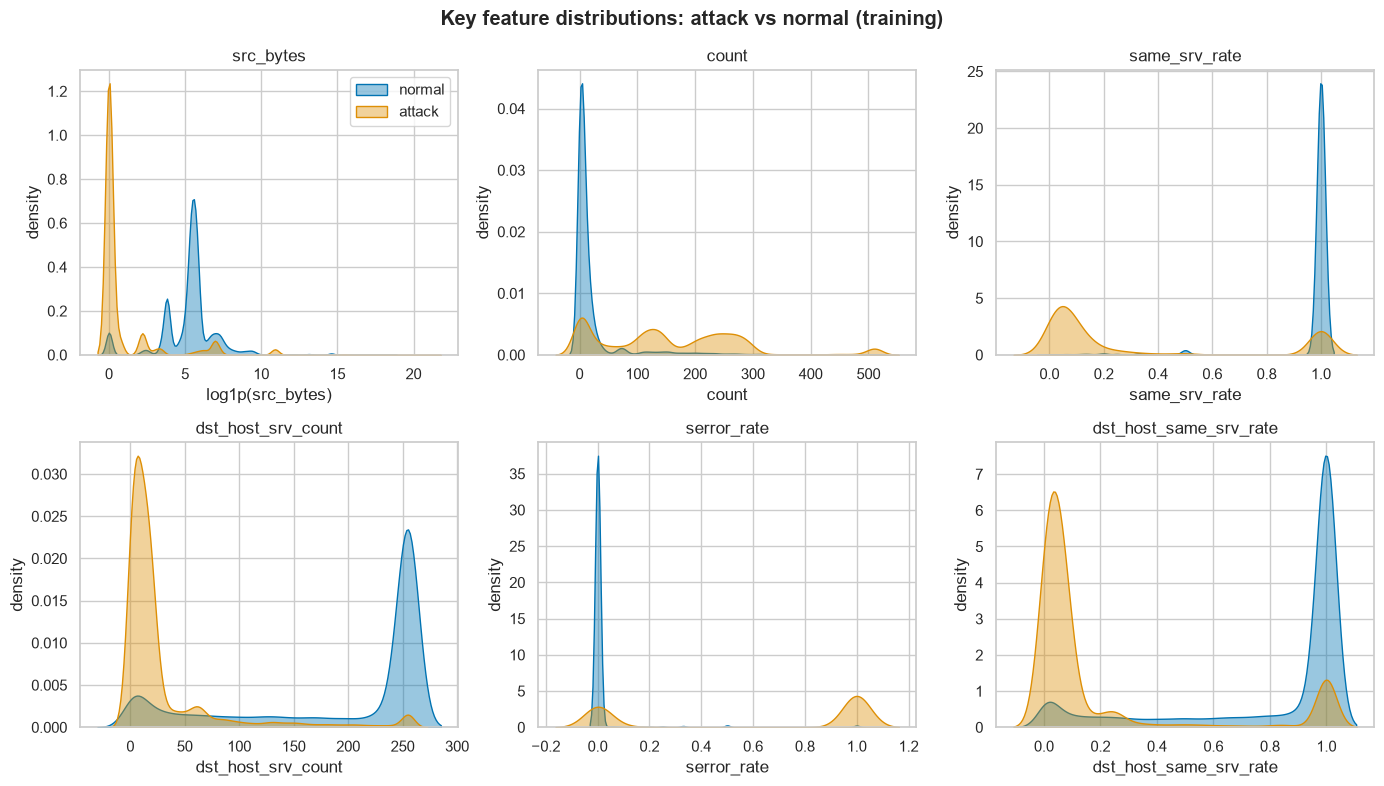

In [10]:
key = ["src_bytes", "count", "same_srv_rate", "dst_host_srv_count",
        "serror_rate", "dst_host_same_srv_rate"]
tmp = train.copy()
tmp["class"] = np.where(tmp["binary_label"] == 1, "attack", "normal")
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.ravel(), key):
    data = tmp[[feat, "class"]].copy()
    if feat in ("src_bytes",):  # heavy-tailed -> log1p for visibility
        data[feat] = np.log1p(data[feat]); ax.set_xlabel(f"log1p({feat})")
    else:
        ax.set_xlabel(feat)
    for cls, color in [("normal", PALETTE["normal"]), ("attack", PALETTE["DoS"])]:
        sns.kdeplot(data.loc[data["class"] == cls, feat], ax=ax, fill=True,
                    alpha=0.4, color=color, label=cls, warn_singular=False)
    ax.set_title(feat); ax.set_ylabel("density")
axes[0, 0].legend()
fig.suptitle("Key feature distributions: attack vs normal (training)",
             fontweight="bold")
fig.tight_layout()
savefig(fig, "p1_feature_distributions.png"); plt.show()

**Reading it (security view).** Several features separate the classes cleanly:
attacks cluster at **`same_srv_rate` ≈ 1** and high **`count`** (many
connections to the same service in a short window — the DoS/Probe signature),
and at **`serror_rate` ≈ 1** (half-open connections). Normal traffic spreads
across a wider `dst_host_srv_count` and non-trivial `src_bytes`. Good news for
DoS/Probe detection. The bad news EDA can't hide: these particular features do
**not** separate R2L/U2R well — those attacks look almost like normal sessions
at the traffic-statistics level and reveal themselves only in content features
(`hot`, `num_failed_logins`, `root_shell`) that are rare and noisy. Set
expectations accordingly for Phases 3–4.

## 7. EDA takeaways → modelling decisions

- **Evaluate with macro-F1 + per-class recall**, not accuracy — the 0.04% U2R
  class makes accuracy meaningless.
- **Keep the official split**; the train→test shift (R2L 0.8%→12.8%) is the
  point, not a bug. It's a proxy for real-world novelty.
- **Encode `service`/`flag`/`protocol_type`** with an encoder that tolerates
  unseen categories at test time (`handle_unknown="ignore"`).
- **Expect strong DoS/Probe detection, weak R2L/U2R** — the rare classes lack
  separating signal in traffic features. This motivates the imbalance-handling
  arsenal (class weights / SMOTE) explored later.
- **Tree ensembles are the natural baseline** given non-linear, correlated,
  mixed-type features; the MLP must justify its added complexity against them.

Next: **Phase 2** — turn these decisions into a reusable `ColumnTransformer`
preprocessing pipeline.